## Kaggle Flight Data Analysis Python Project
Analysis and projections of various metrics (Airline, Destination, Arrival Time, etc) for flights in India from a Kaggle dataset using Python.

## Import Python Libraries
Importing Pandas, Numpy, MatPlotLib, and Seaborn for effective data maniuplation and visualization.

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

## Load Dataset
Importing CSV file for Flight Data in India

In [77]:
df = pd.read_csv('airlines_flights_data.csv')

## Exploring Data Frames
Displaying data to understand data formmating and structure
We see that there are 300,152 rows with 11 columns; 4 are integers/floats and 7 are strings

In [78]:
df.info()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


## Data Cleaning
Removing redundant Index column and assigning it to new dataframe

In [79]:
df_cleaned = df.drop(columns=['index'])
df_cleaned.head(12)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
5,Vistara,UK-945,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,5955
6,Vistara,UK-927,Delhi,Morning,zero,Morning,Mumbai,Economy,2.08,1,6060
7,Vistara,UK-951,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.17,1,6060
8,GO_FIRST,G8-334,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.17,1,5954
9,GO_FIRST,G8-336,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.25,1,5954


Checking for null or duplicate values

In [80]:
df.isnull().sum()
## No null values found

index               0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [81]:
df[df.duplicated()] 
## No duplicate values found

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price


## Feature Engineering
Adding column that has price in USD.

In [82]:
df_cleaned['price (USD $)'] = (df_cleaned['price'] * .012).round(2)
df_cleaned[['price (USD $)']].head(12)

,price (USD $)
0,71.44
1,71.44
2,71.47
3,71.46
4,71.46
5,71.46
6,72.72
7,72.72
8,71.45
9,71.45


Adding column that has price per hour in USD.

In [83]:
df_cleaned['price per hour (USD $)'] = (df_cleaned['price (USD $)'] / df_cleaned['duration']).round(2)
df_cleaned[['price per hour (USD $)']].head(12)

,price per hour (USD $)
0,32.92
1,30.66
2,32.94
3,31.76
4,30.67
5,30.67
6,34.96
7,33.51
8,32.93
9,31.76


## Summary Statistics
Mean, Median, Quartiles, etc

In [84]:
df_cleaned.describe()

,duration,days_left,price,price (USD $),price per hour (USD $)
count,300153.000000,300153.000000,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523,250.676072,26.105617
std,7.191997,13.561004,22697.767366,272.373277,32.801169
min,0.830000,1.000000,1105.000000,13.260000,1.240000
25%,6.830000,15.000000,4783.000000,57.400000,5.520000
50%,11.250000,26.000000,7425.000000,89.100000,11.740000
75%,16.170000,38.000000,42521.000000,510.250000,34.710000
max,49.830000,49.000000,123071.000000,1476.850000,341.680000


## Categorical Variable Exploratory Data Analysis
Let's start by finding the airline frequencies in the dataset

In [85]:
df_cleaned['airline'].value_counts()
## Let's graph this to get a better visualization of the spread.

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

Airline Frequency Bar Graph

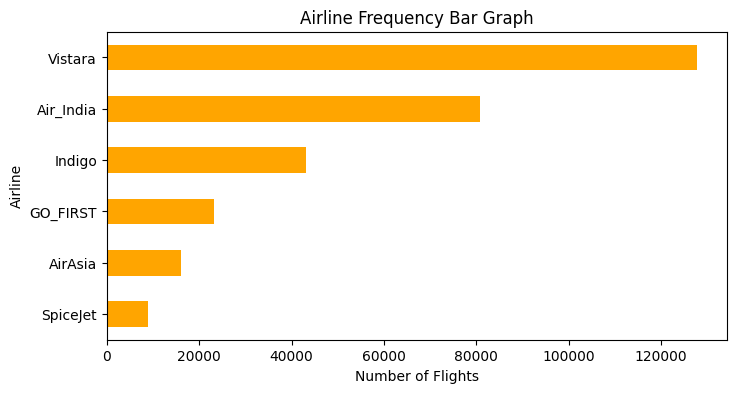

In [86]:
df_cleaned['airline'].value_counts(ascending = True).plot.barh(color='orange', figsize=(8,4))
plt.title('Airline Frequency Bar Graph')
plt.xlabel('Number of Flights')
plt.ylabel('Airline')
plt.show()

Vistara is the most flown airline and SpiceJet is the least flown.
This can be due to price, quality, destinations, flight timings, or more. 
We'll explore this further in the analysis portion.

Departure and Arrival Time Bar Graphs using Subplot Feature

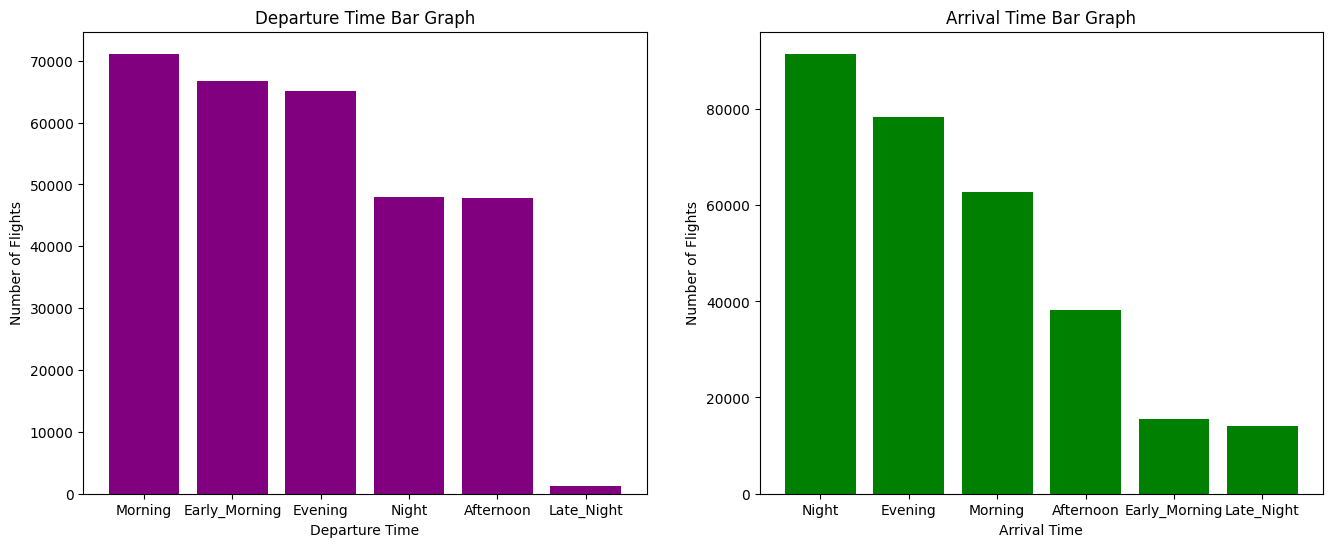

In [87]:
plt.figure(figsize=(16,6))

plt.subplot(1, 2, 1)
plt.bar(df_cleaned['departure_time'].value_counts().index, df_cleaned['departure_time'].value_counts().values, color='purple')
plt.title('Departure Time Bar Graph')
plt.xlabel('Departure Time')
plt.ylabel('Number of Flights')

plt.subplot(1, 2, 2)
plt.bar(df_cleaned['arrival_time'].value_counts().index, df_cleaned['arrival_time'].value_counts().values, color='green')
plt.title('Arrival Time Bar Graph')
plt.xlabel('Arrival Time')
plt.ylabel('Number of Flights')

plt.show()


Morning is the most common departure time and Late Night is the least common departure time.
Night is the most common arrival time and Late Night is the leas common arrival time.

This information can be helpful for airports who can plan around high and low demand based on flight arrivals and departures. Therefore, airports can anticipate higher demand in the mornings and evenings. 

Source and Destination City Bar Graphs using Subplot Feature

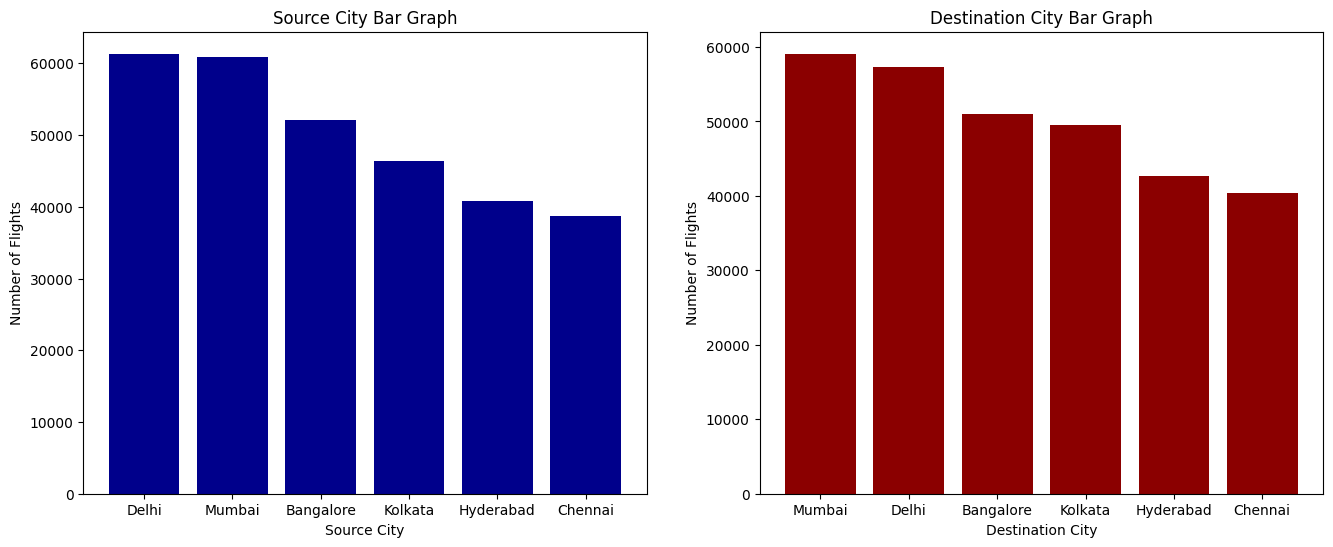

In [88]:
plt.figure(figsize=(16,6))
plt.subplot(1, 2, 1)

plt.bar(df_cleaned['source_city'].value_counts().index, df_cleaned['source_city'].value_counts().values, color='darkblue')
plt.title('Source City Bar Graph')
plt.xlabel('Source City')
plt.ylabel('Number of Flights')

plt.subplot(1, 2, 2)
plt.bar(df_cleaned['destination_city'].value_counts().index, df_cleaned['destination_city'].value_counts().values, color='darkred')
plt.title('Destination City Bar Graph')
plt.xlabel('Destination City')
plt.ylabel('Number of Flights')

plt.show()


Delhi is the most common source city and Chennai is the least common source city.
Mumbai the most common destination city and Chennai is the least common destination city.

This shows us where the higher populations and more popular tourist destinations in India are, since most flights are between big cities like Delhi and Mumbai, while Hyderabad and Chennai are less populous and visited since they have the least amount of flights.

As shown above, the subplot feature helps combine similar variables into one output

## Airline Price Variation Analysis
Now let's look at the price variations, starting by grouping prices by airline

In [89]:
df_cleaned.groupby('airline')['price'].mean()

airline
AirAsia       4091.072742
Air_India    23507.019112
GO_FIRST      5652.007595
Indigo        5324.216303
SpiceJet      6179.278881
Vistara      30396.536302
Name: price, dtype: float64

Air India and Vistara have much higher average prices than the other airlines, we'll keep an eye out for that in our analysis.

Let's plot these averages using seaborn with different numerical hues to see if we can find the reason

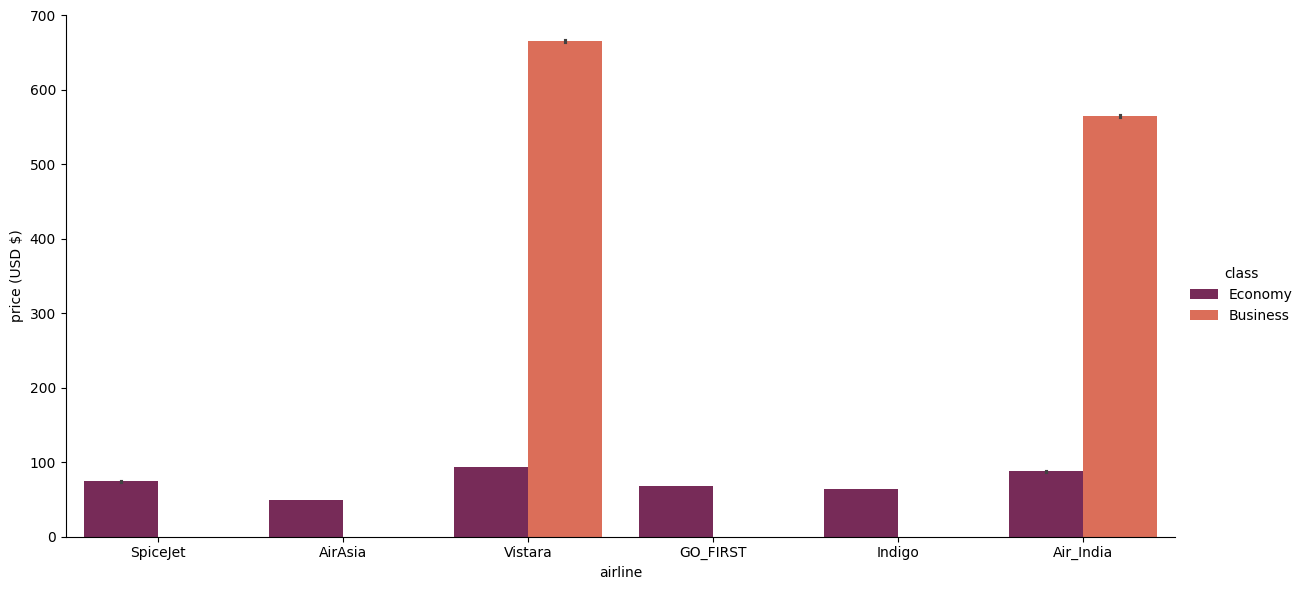

In [90]:
sns.catplot(x='airline', y='price (USD $)', data=df_cleaned, kind='bar', palette='rocket', hue='class', height=6, aspect=2)
plt.show()

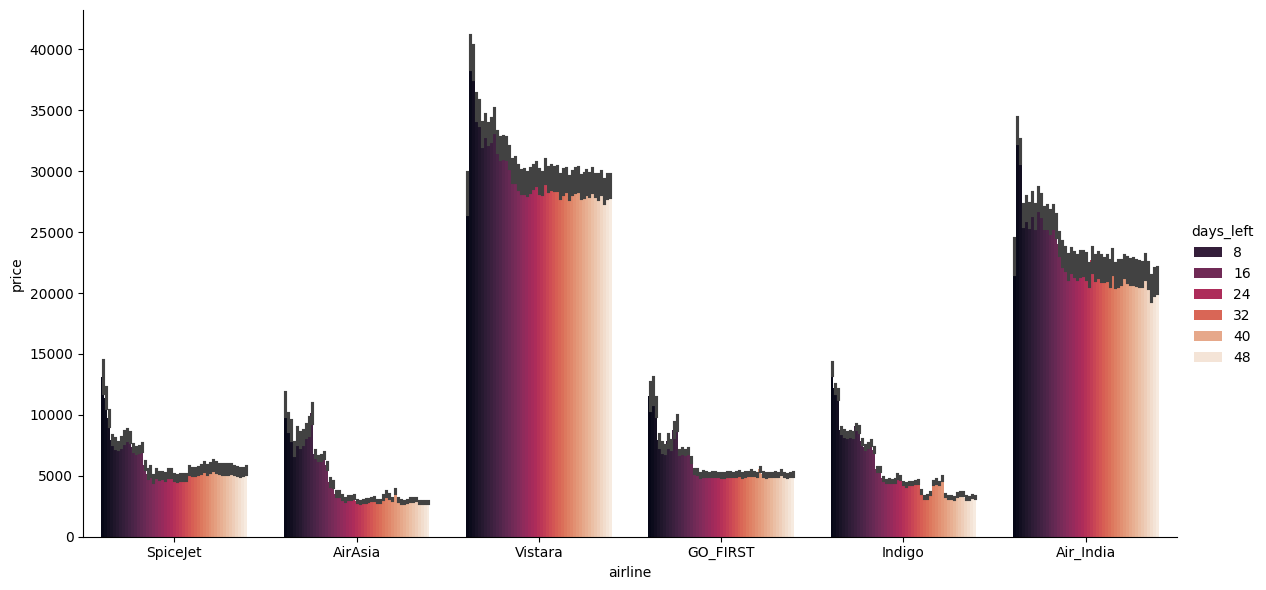

In [91]:
sns.catplot(x='airline', y='price', data=df_cleaned, kind='bar', palette='rocket', hue='days_left', height=6, aspect=2)
plt.show()

After filtering for both class and number of days booked before the flight, it looks like the reason Vistara and Air India have much higher averages because they include business class flights as well, which will naturally have higher prices than economy tickets. We can also conclude that the number of days booked has no effect on any airline in particular, since the same trend is repeated for each airline, which we will get into later.

For just economy tickets, AirAsia has the lowest average ticket prices while Vistara has the highest average.
This shows that price is probably not as strong of a predictor for the airline flown, since the most popular airline in this dataset is Vistara, even though it has the highest average ticket price. 
Let's explore further. 

Let's compare this with Price per Hour in a subplot to look at operational efficiency.

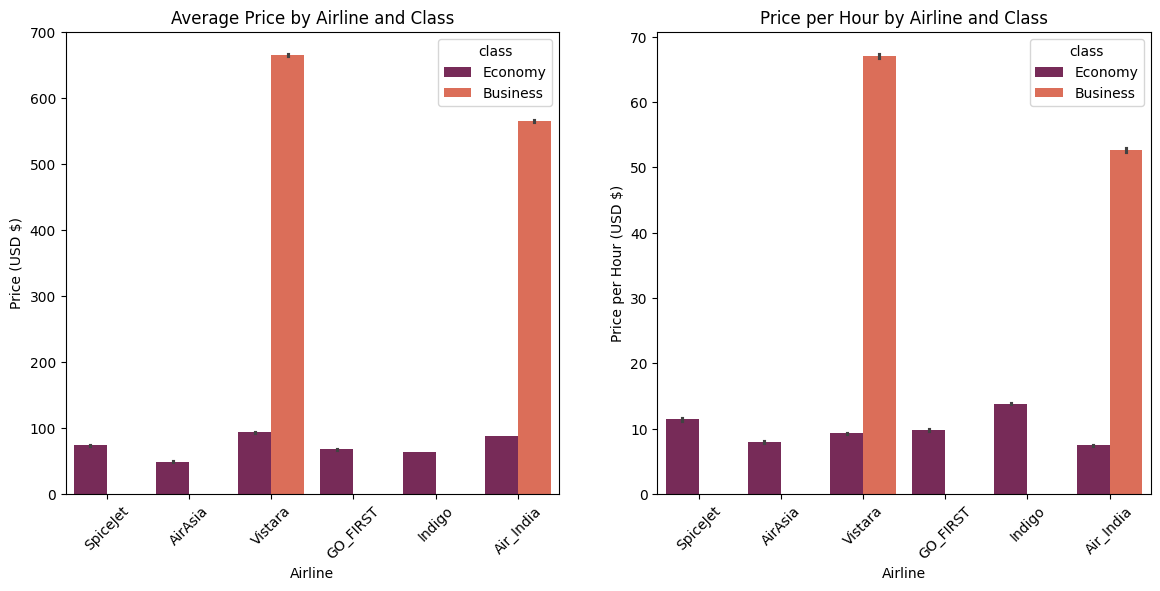

In [92]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='airline', y='price (USD $)', data=df_cleaned, hue='class', palette='rocket')
plt.title('Average Price by Airline and Class')
plt.xlabel('Airline')
plt.ylabel('Price (USD $)')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.barplot(x='airline', y='price per hour (USD $)', data=df_cleaned, hue='class', palette='rocket')
plt.title('Price per Hour by Airline and Class')
plt.xlabel('Airline')
plt.ylabel('Price per Hour (USD $)')
plt.xticks(rotation=45)

plt.show()

Air India has the lowest $ cost per hour while Indigo has the highest, indicating that once flight time is considered, the seemingly more expensive airlines are actually more cost efficient on an hourly basis. This helps passengers save money when booking and gives airlines more context when comparing operational efficiency.

## Depature and Arrival Time Price Variation Analysis
Let's see if the flight timing might be a correlating factor for the price while only counting tickets in economy class.

In [93]:
df_cleaned[df_cleaned['class'] == 'Economy'].groupby('departure_time')['price'].mean()


departure_time
Afternoon        6473.095872
Early_Morning    6560.315392
Evening          6360.750741
Late_Night       4784.699486
Morning          7119.019664
Night            6205.964764
Name: price, dtype: float64

In [94]:
df_cleaned[df_cleaned['class'] == 'Economy'].groupby('arrival_time')['price'].mean()

arrival_time
Afternoon        6407.028152
Early_Morning    5336.658237
Evening          7206.771859
Late_Night       5173.086538
Morning          6416.474542
Night            6727.078912
Name: price, dtype: float64

Looks like the prices are mostly similar across timings. Let's graph these with a line relational plot using Seaborn to better uncover any hidden price variations by arrival time and class, while separating the data by departure time to see if certain departure windows affect pricing trends differently and filtering for class.

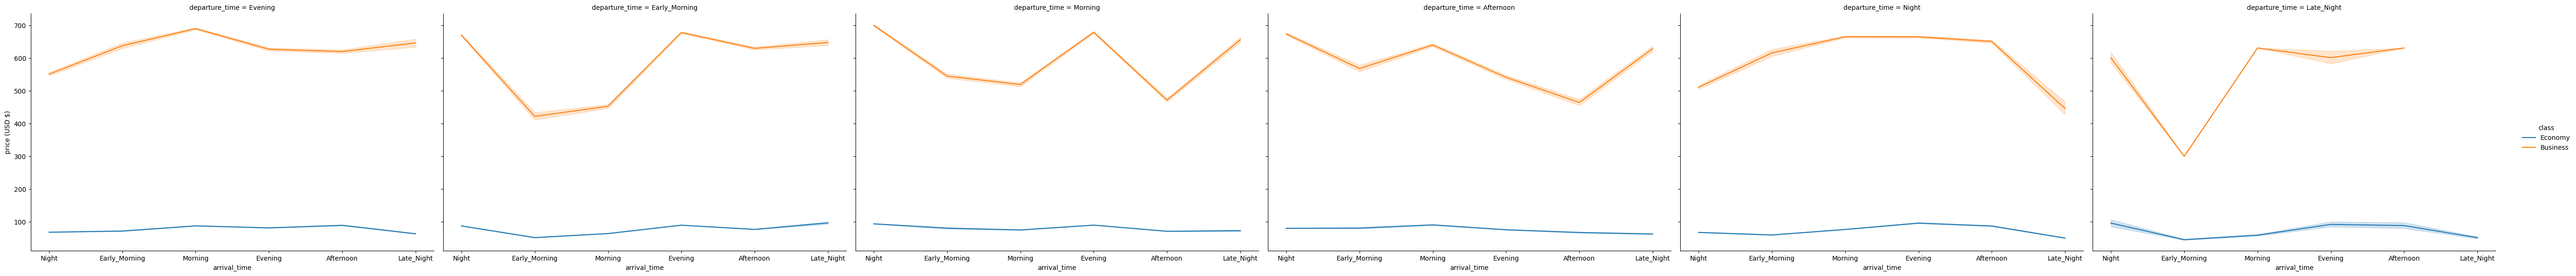

In [95]:
sns.relplot(x='arrival_time', y='price (USD $)', data=df_cleaned, kind = 'line', hue='class', col = 'departure_time', palette='tab10', height=6, aspect=1.5)

plt.show()

Looks like this confirms little variation for economy passengers based on flight timings, but more variation for business class passengers for early morning and late night departures. Let's do this for price per hour to uncover more insights.

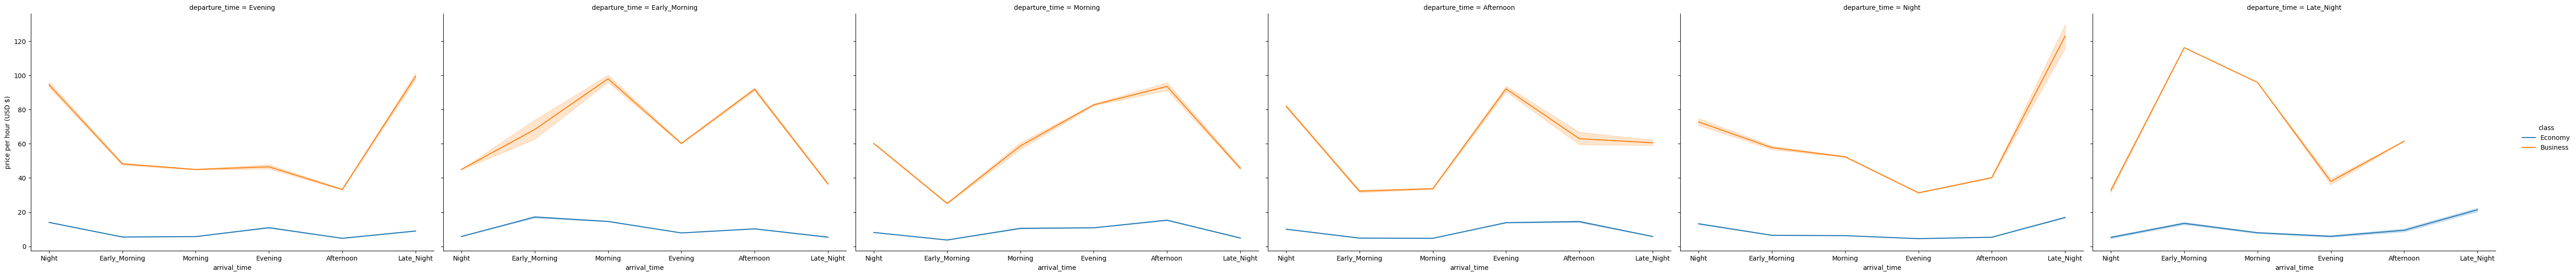

In [96]:
sns.relplot(x='arrival_time', y='price per hour (USD $)', data=df_cleaned, kind = 'line', hue='class', col = 'departure_time', palette='tab10', height=6, aspect=1.5)

plt.show()

These plots confirm that the flight timing does affect the price for business class passengers, with substantial dips in prices with departure times in the morning and night/late night, but economy class still shows constant prices even when filtered for price per hour. Therefore, business class passengers are the passengers that can save the most money due to the variation in prices based on flight timings. 

## Depature and Arrival Destination Price Variation Analysis
Let's see if the source and arrival destinates might be a correlating factor for the price while only counting tickets in economy class. 

In [97]:
df_cleaned[df_cleaned['class'] == 'Economy'].groupby('source_city')['price'].mean()

source_city
Bangalore    6582.057019
Chennai      6606.279699
Delhi        6288.585423
Hyderabad    6235.770619
Kolkata      7458.632354
Mumbai       6358.920050
Name: price, dtype: float64

In [98]:
df_cleaned[df_cleaned['class'] == 'Economy'].groupby('destination_city')['price'].mean()

destination_city
Bangalore    6618.316318
Chennai      6641.605072
Delhi        6251.088579
Hyderabad    6305.544732
Kolkata      7200.518058
Mumbai       6459.578293
Name: price, dtype: float64

Seems like there is not as much variation for destinations as well. Let's use a relational plot again to uncover more insights.

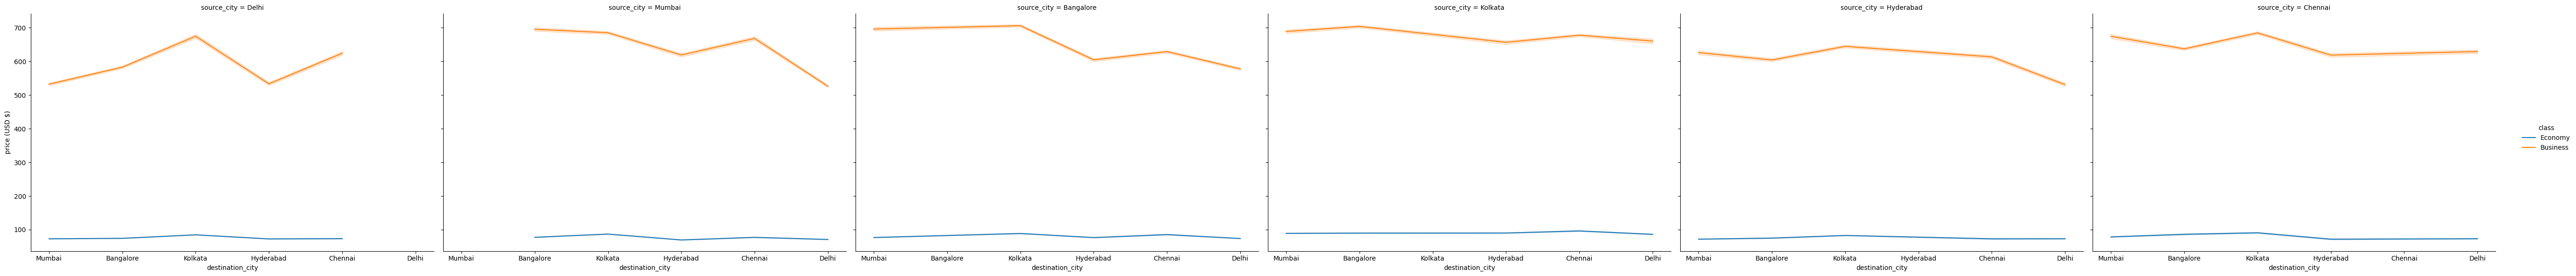

In [99]:
sns.relplot(x='destination_city', y='price (USD $)', data=df_cleaned, kind = 'line', hue='class', col = 'source_city', palette='tab10', height=6, aspect=1.5)

plt.show()

As with departure and arrival time, it seems there isn't any variation in prices when looking at destination and source cities for economy class passengers, with only modest variations for business class passengers between Delhi and Hyderabad. 

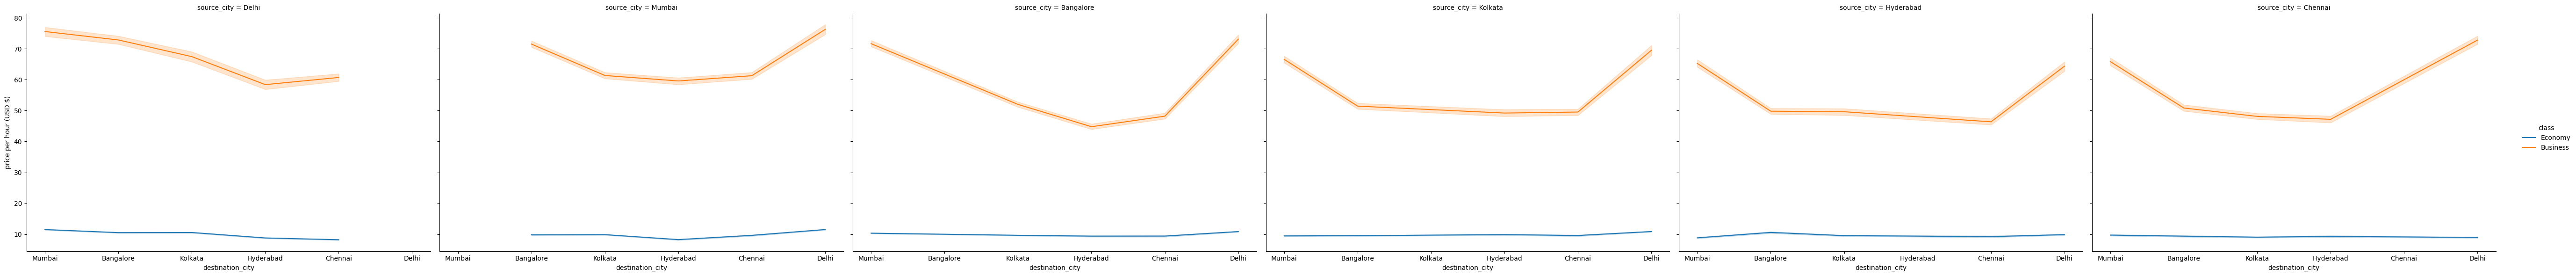

In [100]:
sns.relplot(x='destination_city', y='price per hour (USD $)', data=df_cleaned, kind = 'line', hue='class', col = 'source_city', palette='tab10', height=6, aspect=1.5)

plt.show()

When we look at price per hour, we see that the further augmented variation for business class passengers is mainly for Hyderabad, Kolkata, and Chennai. Therefore, potential passengers who want to fly business class for less should choose those destinations, while economy class passengers are uneffected. 

## Time before Booking Price Analysis
Let's see how the number of days the tickets were booked before the actual day of the flight affects the ticket price.

In [101]:
df_cleaned[df_cleaned['class'] == 'Economy'].groupby('days_left')['price'].mean()

days_left
1     14613.179410
2     13980.828244
3     13174.050992
4     10901.386284
5     10605.918315
6     10319.679864
7     10471.873164
8     10479.491889
9     11352.916150
10    11187.502450
11     9580.689797
12     9317.772057
13     9363.530525
14     9454.915150
15     8379.261405
16     6338.468699
17     6169.793188
18     5430.142104
19     5330.167910
20     5284.451684
21     5225.473381
22     5381.483499
23     5581.506998
24     5534.275241
25     5094.623277
26     5010.905106
27     5057.053793
28     5112.103784
29     5240.071105
30     5338.556293
31     5017.156264
32     4790.014994
33     4806.161612
34     4959.457428
35     5208.670623
36     5166.054469
37     5218.408686
38     5572.666372
39     4854.074604
40     4739.729790
41     4774.031208
42     4783.826966
43     4893.282565
44     4890.226095
45     4908.194591
46     4704.503549
47     4669.652956
48     4717.688994
49     4750.805113
Name: price, dtype: float64

In [102]:
df_cleaned[df_cleaned['class'] == 'Business'].groupby('days_left')['price'].mean()

days_left
1     65169.312030
2     60455.848506
3     60313.822331
4     56120.287087
5     56149.915397
6     53643.310488
7     54501.171604
8     53224.650386
9     52981.195297
10    54247.303856
11    51845.794695
12    51991.619675
13    52172.086514
14    52441.797235
15    52374.451431
16    52063.309830
17    52824.242843
18    52334.639336
19    52113.802120
20    52384.847236
21    51919.704211
22    52008.284992
23    51890.213597
24    52539.281974
25    51664.004365
26    51536.578109
27    52183.743781
28    52074.678982
29    52077.936396
30    52057.186869
31    52360.828629
32    51264.440488
33    51810.985112
34    51869.054609
35    51475.459162
36    51924.139056
37    51808.754280
38    52150.719697
39    51214.290386
40    51406.713790
41    52153.949178
42    51583.182456
43    52092.968703
44    51383.279592
45    51160.208098
46    51209.790072
47    51742.102235
48    51558.758230
49    51124.505820
Name: price, dtype: float64

Looks like there is a substantial variation when it comes to number of days booked in advance, let's use a relational plot as before to better visualize the many different values.

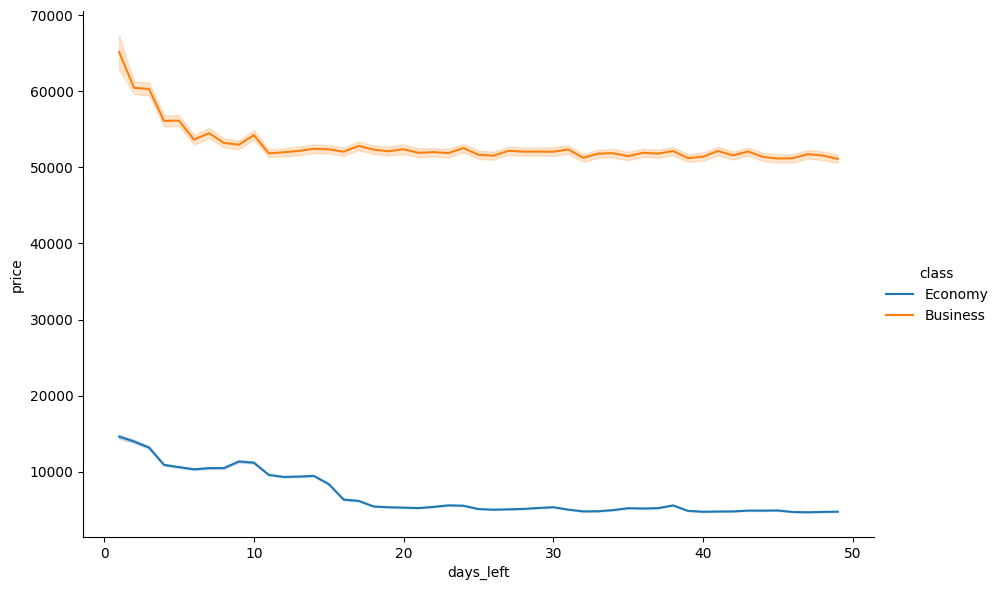

In [103]:
sns.relplot(x='days_left', y='price', data=df_cleaned, kind = 'line', hue='class', palette='tab10', height=6, aspect=1.5)

plt.show()

This graph clearly shows that prices tend to be higher when booked closer to the day of the flight, affecting business class passengers more due to the steeper slope from 10 days booked to the day of flight compared to economy class passengers. Let's look at price per hour to double check this conclusion. 

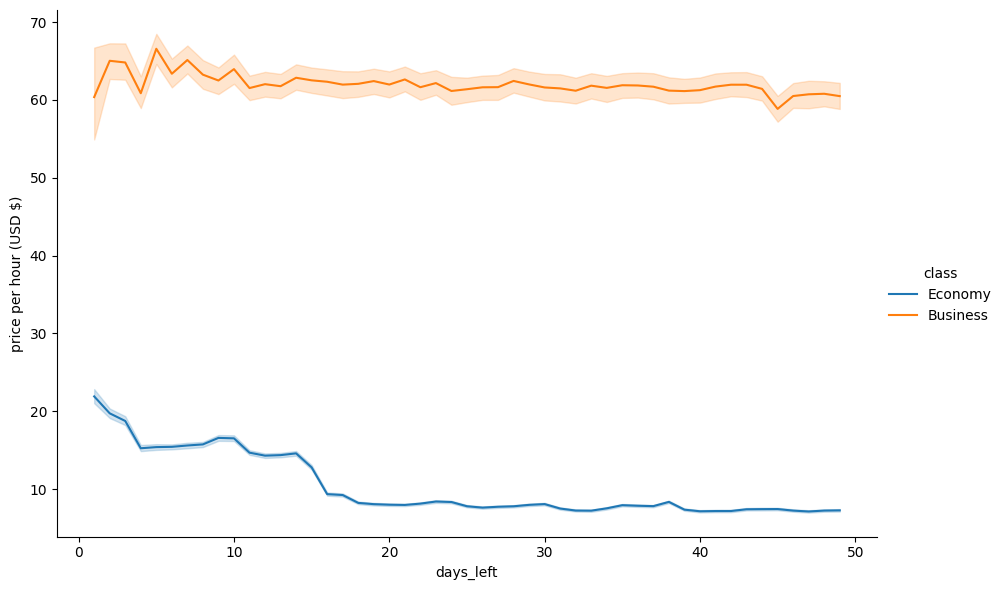

In [104]:
sns.relplot(x='days_left', y='price per hour (USD $)', data=df_cleaned, kind = 'line', hue='class', palette='tab10', height=6, aspect=1.5)

plt.show()

When looking at price per hour, we see generally the same trend but more augmented for economy passengers and less so for business passengers. Overall, the conclusion stands that as the days before booking decreases, the price increases at around the 10-15 day mark.

## Economy vs Business Price Analysis
Let's look at how class affects the price irrespective of airline as from the beginning of the project.

In [105]:
df_cleaned[df_cleaned['class'] == 'Economy']['price'].mean()

np.float64(6572.342383362527)

In [106]:
df_cleaned[df_cleaned['class'] == 'Business']['price'].mean()

np.float64(52540.08112357868)

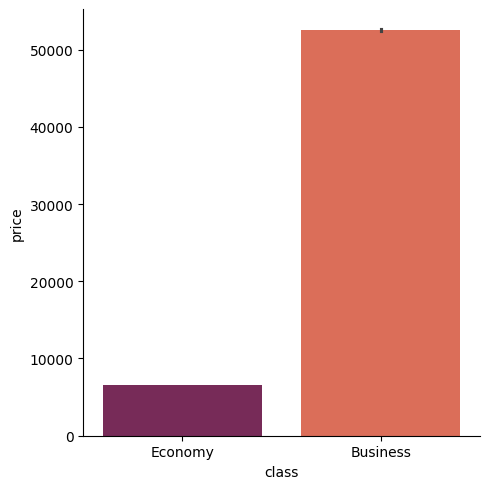

In [107]:
sns.catplot(x='class', y='price', data=df_cleaned, kind='bar', palette='rocket', hue='class')
plt.show()

As we can see, a clear difference between economy and business class prices, with the average difference between 10 fold.

## Case Study: What is the Average Business Class Fare for Flights from Delhi to Hyderaba on Vistara?
Let's use the 'and' operator

In [108]:
df_cleaned[(df_cleaned['airline'] == 'Vistara') & (df_cleaned['source_city'] == 'Delhi') & (df_cleaned['destination_city'] == 'Hyderabad') & (df_cleaned['class'] == 'Business')]['price'].mean()

np.float64(47939.840361445786)

Mean price is 47,939.84 INR 

## Key Insights
• Price-per-hour analysis reveals airlines with much higher or lower unit costs than absolute fares suggest.

• Business vs Economy: Business class consistently commands a premium; the size of the premium varies by route.

• Booking lead-time affects fares: As the number of days to departure decreases below 10-15 days, fares increase substantially.

• Time-of-day matters: Certain departure windows, such as morning and early morning, tend to have higher fares and different durations.